In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Load raw data from URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fJKLoMKtgpDAl5MkA6rf2A/jfk-weather.csv"
raw_data = pd.read_csv(url, parse_dates=['DATE'])

#show the first 5 rows of the data
raw_data.head()


C:\Users\kavia\AppData\Local\Temp\ipykernel_10740\2097435739.py:12: DtypeWarning: Columns (8,10,11,12,13,14,15,16,17,20,22,23,25,40,63,64,67,68,69,84,85,86,87) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv(url, parse_dates=['DATE'])


,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,DATE,REPORTTPYE,HOURLYSKYCONDITIONS,HOURLYVISIBILITY,HOURLYPRSENTWEATHERTYPE,...,MonthlyMaxSeaLevelPressureTime,MonthlyMinSeaLevelPressureValue,MonthlyMinSeaLevelPressureDate,MonthlyMinSeaLevelPressureTime,MonthlyTotalHeatingDegreeDays,MonthlyTotalCoolingDegreeDays,MonthlyDeptFromNormalHeatingDD,MonthlyDeptFromNormalCoolingDD,MonthlyTotalSeasonToDateHeatingDD,MonthlyTotalSeasonToDateCoolingDD
0,WBAN:94789,JFK INTERNATIONAL AIRPORT NY US,3.4,40.6386,-73.7622,2010-01-01 00:51:00,FM-15,FEW:02 7 SCT:04 13 BKN:07 29,6.00,-RA:02 PL:06 BR:1 |RA:61 PL:74 |RA:61 PL:79,...,-9999,NaN,-9999,-9999,NaN,NaN,NaN,NaN,NaN,NaN
1,WBAN:94789,JFK INTERNATIONAL AIRPORT NY US,3.4,40.6386,-73.7622,2010-01-01 01:00:00,FM-12,NaN,5.59,||PL:79,...,-9999,NaN,-9999,-9999,NaN,NaN,NaN,NaN,NaN,NaN
2,WBAN:94789,JFK INTERNATIONAL AIRPORT NY US,3.4,40.6386,-73.7622,2010-01-01 01:51:00,FM-15,FEW:02 6 SCT:04 13 OVC:08 35,6.00,-RA:02 PL:06 BR:1 |RA:61 PL:74 |RA:61 PL:79,...,-9999,NaN,-9999,-9999,NaN,NaN,NaN,NaN,NaN,NaN
3,WBAN:94789,JFK INTERNATIONAL AIRPORT NY US,3.4,40.6386,-73.7622,2010-01-01 02:03:00,FM-16,FEW:02 6 SCT:04 13 OVC:08 35,6.00,-RA:02 BR:1 |RA:61 |RA:61,...,-9999,NaN,-9999,-9999,NaN,NaN,NaN,NaN,NaN,NaN
4,WBAN:94789,JFK INTERNATIONAL AIRPORT NY US,3.4,40.6386,-73.7622,2010-01-01 02:28:00,FM-16,BKN:07 7 BKN:07 15 OVC:08 35,5.00,-RA:02 BR:1 |RA:61 |RA:61,...,-9999,NaN,-9999,-9999,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Select only relevant columns for analysis
column_subset = [
    'DATE', 'HOURLYVISIBILITY', 'HOURLYDRYBULBTEMPF', 'HOURLYWETBULBTEMPF',
    'HOURLYDewPointTempF', 'HOURLYRelativeHumidity', 'HOURLYWindSpeed',
    'HOURLYWindDirection', 'HOURLYStationPressure', 'HOURLYPressureTendency',
    'HOURLYSeaLevelPressure', 'HOURLYPrecip', 'HOURLYAltimeterSetting'
]
#Create a new dataframe with these columns
hourly_data = raw_data[column_subset].copy()
# View the first few rows of the new dataframe
hourly_data.head()

,DATE,HOURLYVISIBILITY,HOURLYDRYBULBTEMPF,HOURLYWETBULBTEMPF,HOURLYDewPointTempF,HOURLYRelativeHumidity,HOURLYWindSpeed,HOURLYWindDirection,HOURLYStationPressure,HOURLYPressureTendency,HOURLYSeaLevelPressure,HOURLYPrecip,HOURLYAltimeterSetting
0,2010-01-01 00:51:00,6.00,33.0,32.0,31,92.0,0.0,000,29.97,8.0,29.99,0.01,29.99
1,2010-01-01 01:00:00,5.59,33.0,32.0,31,92.0,0.0,000,29.96,8.0,29.99,NaN,NaN
2,2010-01-01 01:51:00,6.00,33.0,33.0,32,96.0,0.0,000,29.97,NaN,29.99,0.02,29.99
3,2010-01-01 02:03:00,6.00,34.0,33.0,32,93.0,0.0,000,29.97,NaN,NaN,T,29.99
4,2010-01-01 02:28:00,5.00,34.0,33.0,32,93.0,0.0,000,29.97,NaN,NaN,T,29.99


In [3]:
# Check current data types
hourly_data.dtypes

DATE                      datetime64[ns]
HOURLYVISIBILITY                  object
HOURLYDRYBULBTEMPF                object
HOURLYWETBULBTEMPF                object
HOURLYDewPointTempF               object
HOURLYRelativeHumidity            object
HOURLYWindSpeed                   object
HOURLYWindDirection               object
HOURLYStationPressure             object
HOURLYPressureTendency           float64
HOURLYSeaLevelPressure            object
HOURLYPrecip                      object
HOURLYAltimeterSetting            object
dtype: object

In [4]:
#  Data Cleaning 

# 1. Replace '*' with NaN and 'T' with 0.00
hourly_data.replace('*', np.nan, inplace=True)
hourly_data['HOURLYPrecip'] = hourly_data['HOURLYPrecip'].replace('T', '0.00')

# Function to clean and convert strings to float
def clean_float(value):
    # Everything inside the function must be indented (pushed to the right)
    if pd.isna(value) or value == '':
        return np.nan
    
    # Remove letters
    value = re.sub('[^0-9,.-]', '', str(value))
    
    # If there are two dots (e.g. 0.02.01), take only the first part     
    if value.count('.') > 1:
        parts = value.split('.')
        value = parts[0] + '.' + parts[1]
    
    try:
        return float(value)
    except:
        return np.nan

# Apply cleaning to all columns except DATE
columns_to_fix = column_subset[1:]
for col in columns_to_fix:
    hourly_data[col] = hourly_data[col].apply(clean_float).astype('float32')

# Show results
print("Data Cleaning Successful!")
hourly_data.info()
hourly_data.head()

Data Cleaning Successful!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114545 entries, 0 to 114544
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   DATE                    114545 non-null  datetime64[ns]
 1   HOURLYVISIBILITY        96464 non-null   float32       
 2   HOURLYDRYBULBTEMPF      111403 non-null  float32       
 3   HOURLYWETBULBTEMPF      111245 non-null  float32       
 4   HOURLYDewPointTempF     111395 non-null  float32       
 5   HOURLYRelativeHumidity  111395 non-null  float32       
 6   HOURLYWindSpeed         111358 non-null  float32       
 7   HOURLYWindDirection     110444 non-null  float32       
 8   HOURLYStationPressure   111256 non-null  float32       
 9   HOURLYPressureTendency  48038 non-null   float32       
 10  HOURLYSeaLevelPressure  99522 non-null   float32       
 11  HOURLYPrecip            79763 non-null   float32       
 12  HOUR

,DATE,HOURLYVISIBILITY,HOURLYDRYBULBTEMPF,HOURLYWETBULBTEMPF,HOURLYDewPointTempF,HOURLYRelativeHumidity,HOURLYWindSpeed,HOURLYWindDirection,HOURLYStationPressure,HOURLYPressureTendency,HOURLYSeaLevelPressure,HOURLYPrecip,HOURLYAltimeterSetting
0,2010-01-01 00:51:00,6.00,33.0,32.0,31.0,92.0,0.0,0.0,29.969999,8.0,29.99,0.01,29.99
1,2010-01-01 01:00:00,5.59,33.0,32.0,31.0,92.0,0.0,0.0,29.959999,8.0,29.99,NaN,NaN
2,2010-01-01 01:51:00,6.00,33.0,33.0,32.0,96.0,0.0,0.0,29.969999,NaN,29.99,0.02,29.99
3,2010-01-01 02:03:00,6.00,34.0,33.0,32.0,93.0,0.0,0.0,29.969999,NaN,NaN,0.00,29.99
4,2010-01-01 02:28:00,5.00,34.0,33.0,32.0,93.0,0.0,0.0,29.969999,NaN,NaN,0.00,29.99


In [5]:
# Fill missing values to ensure model doesn't crash
# use forward fill and linear interpolation
hourly_data['HOURLYPressureTendency'] = hourly_data['HOURLYPressureTendency'].ffill()
hourly_data = hourly_data.interpolate(method='linear')
hourly_data.dropna(subset=['HOURLYDRYBULBTEMPF'], inplace=True)

# Transform Wind Direction and Pressure Tendency
# This helps the model understand cyclical data and trends
if 'HOURLYWindDirection' in hourly_data.columns:
    hourly_data['wind_direction_sin'] = np.sin(hourly_data['HOURLYWindDirection']*(2.*np.pi/360))
    hourly_data['wind_direction_cos'] = np.cos(hourly_data['HOURLYWindDirection']*(2.*np.pi/360))

if 'HOURLYPressureTendency' in hourly_data.columns:
    hourly_data['pressure_tend_incr'] = [1.0 if x in [0,1,2,3] else 0.0 for x in hourly_data['HOURLYPressureTendency']]
    hourly_data['pressure_tend_decr'] = [1.0 if x in [5,6,7,8] else 0.0 for x in hourly_data['HOURLYPressureTendency']]

# Drop old columns safely (Using errors='ignore' to prevent crashes)
hourly_data.drop(['HOURLYWindDirection', 'HOURLYPressureTendency'], axis=1, inplace=True, errors='ignore')

# Rename columns to simple names as per assignment instructions
columns_name_map = {
    'HOURLYVISIBILITY': 'visibility', 
    'HOURLYDRYBULBTEMPF': 'dry_bulb_temp_f',
    'HOURLYWETBULBTEMPF': 'wet_bulb_temp_f', 
    'HOURLYDewPointTempF': 'dew_point_temp_f',
    'HOURLYRelativeHumidity': 'relative_humidity', 
    'HOURLYWindSpeed': 'wind_speed',
    'HOURLYStationPressure': 'station_pressure', 
    'HOURLYSeaLevelPressure': 'sea_level_pressure',
    'HOURLYPrecip': 'precip', 
    'HOURLYAltimeterSetting': 'altimeter_setting'
}
hourly_data.rename(columns=columns_name_map, inplace=True)

# Set DATE as index for Visualization
if 'DATE' in hourly_data.columns:
    hourly_data.set_index('DATE', inplace=True)

hourly_data.head()

,visibility,dry_bulb_temp_f,wet_bulb_temp_f,dew_point_temp_f,relative_humidity,wind_speed,station_pressure,sea_level_pressure,precip,altimeter_setting,wind_direction_sin,wind_direction_cos,pressure_tend_incr,pressure_tend_decr
DATE,,,,,,,,,,,,,,
2010-01-01 00:51:00,6.00,33.0,32.0,31.0,92.0,0.0,29.969999,29.99,0.010,29.99,0.0,1.0,0.0,1.0
2010-01-01 01:00:00,5.59,33.0,32.0,31.0,92.0,0.0,29.959999,29.99,0.015,29.99,0.0,1.0,0.0,1.0
2010-01-01 01:51:00,6.00,33.0,33.0,32.0,96.0,0.0,29.969999,29.99,0.020,29.99,0.0,1.0,0.0,1.0
2010-01-01 02:03:00,6.00,34.0,33.0,32.0,93.0,0.0,29.969999,29.99,0.000,29.99,0.0,1.0,0.0,1.0
2010-01-01 02:28:00,5.00,34.0,33.0,32.0,93.0,0.0,29.969999,29.99,0.000,29.99,0.0,1.0,0.0,1.0


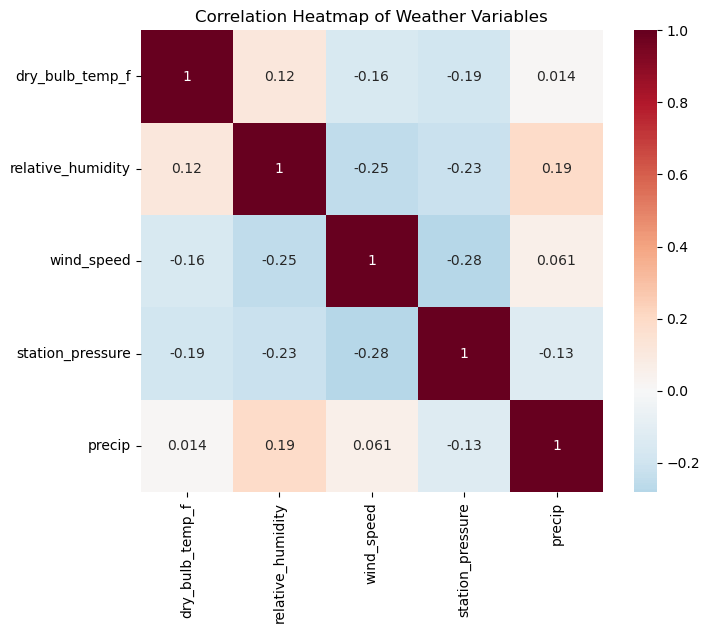

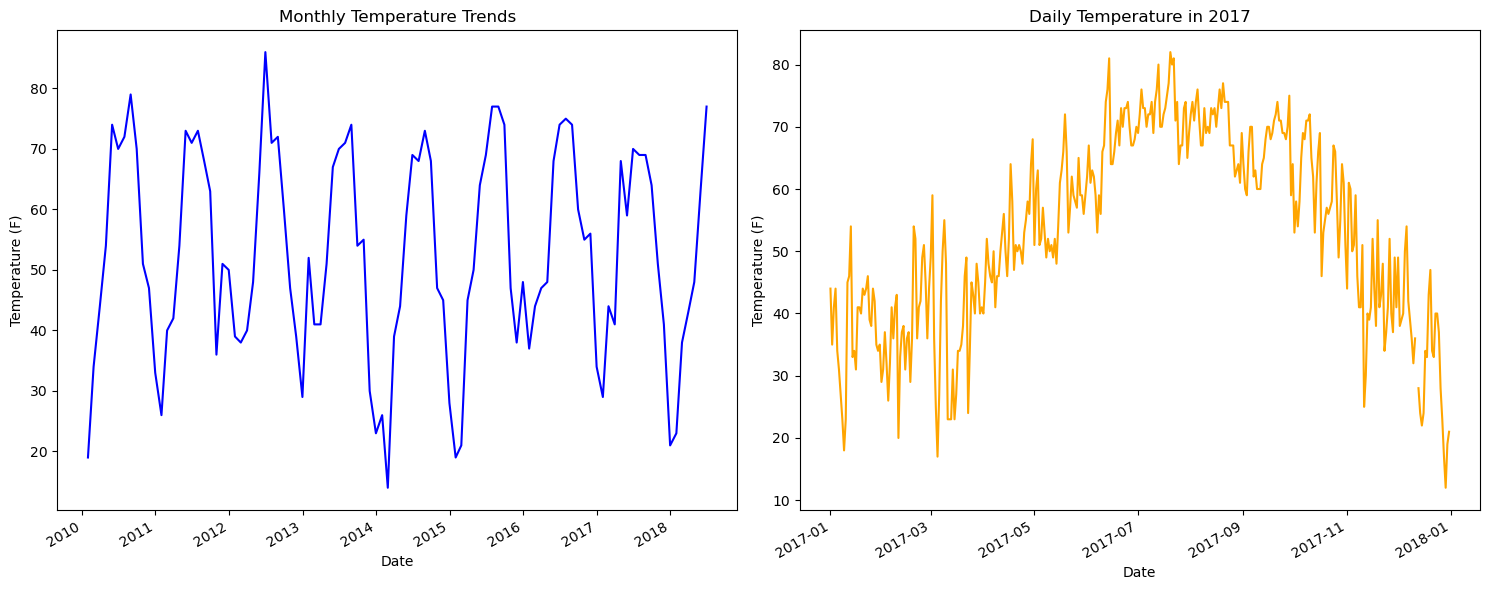

In [11]:
# --- Data Visualization ---

# A. Create a Correlation Heatmap
# select 5 important variables to see how they relate to each other
plot_cols = ['dry_bulb_temp_f', 'relative_humidity', 'wind_speed', 'station_pressure', 'precip']

plt.figure(figsize=(8, 6))
# annot=True shows the numbers, cmap='RdBu_r' gives Red/Blue colors
sns.heatmap(hourly_data[plot_cols].corr(), annot=True, cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap of Weather Variables')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# B. Plot Temperature Trends
plt.figure(figsize=(15, 6))

# Plot 1: Monthly Temperature (Mean of each month)
plt.subplot(1, 2, 1)
hourly_data['dry_bulb_temp_f'].asfreq('ME').plot(color='blue')
plt.title('Monthly Temperature Trends')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')

# Plot 2: Daily Temperature for a specific year (2017)
plt.subplot(1, 2, 2)
hourly_data.loc['2017', 'dry_bulb_temp_f'].asfreq('D').plot(color='orange')
plt.title('Daily Temperature in 2017')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')

plt.tight_layout()
plt.savefig('temperature_trends.png', dpi=300, bbox_inches='tight')
plt.show()

R^2 Score: 0.9952
Mean Squared Error: 1.4118


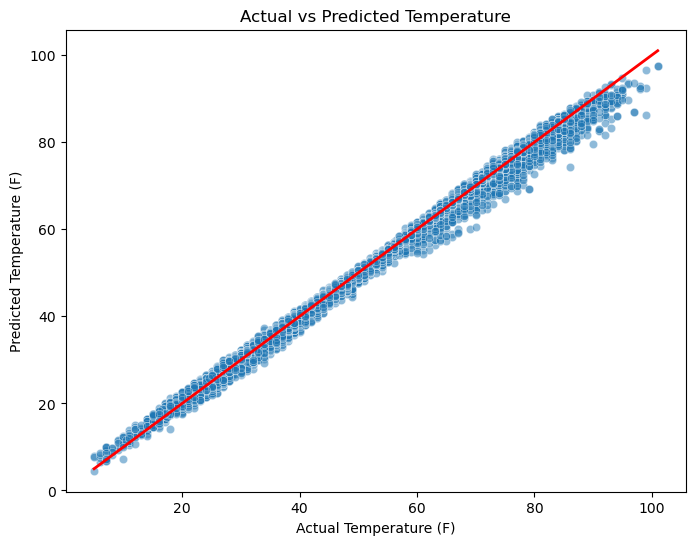

In [12]:
# Linear Regression Model

# 1. Define Features (X) and Target (y)
# Target is what we want to predict (Temperature)
y = hourly_data['dry_bulb_temp_f']
# Features are the data we use to predict (Everything except the temperature)
X = hourly_data.drop(columns=['dry_bulb_temp_f'])

# 2. Split data into Training set (80%) and Testing set (20%)
# random_state=42 ensures get the same results every time we run
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions using the Test data
predictions = model.predict(X_test)

# 5. Evaluate the Model Performance
# R2 Score: 1.0 is perfect prediction
print(f'R^2 Score: {metrics.r2_score(y_test, predictions):.4f}')
# Mean Squared Error: Lower is better
print(f'Mean Squared Error: {metrics.mean_squared_error(y_test, predictions):.4f}')

# 6. Visualize: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Diagonal line
plt.xlabel('Actual Temperature (F)')
plt.ylabel('Predicted Temperature (F)')
plt.title('Actual vs Predicted Temperature')
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()